In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random

In [2]:
x = np.arange(0, 8, 0.2)
noise = np.random.normal(0,0.1, len(x))
y = random.uniform(0,3)*np.sin(random.uniform(0,3)*x)
y_noisy = y+noise

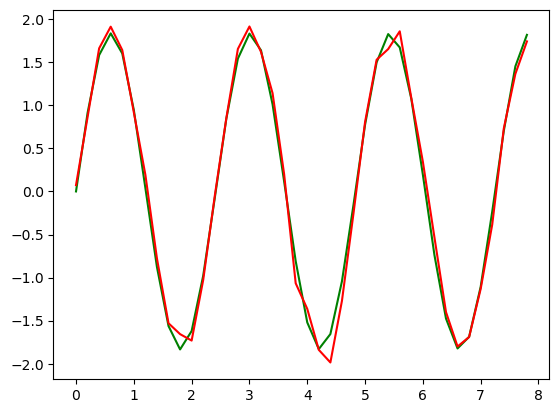

In [3]:
plt.plot(x, y, color='green')
plt.plot(x, y_noisy, color='red')
plt.show()

In [4]:
# Generate database
num_instances = 10000
x = np.arange(0,32,0.2)
signal_length = len(x)

clean = np.zeros((num_instances, signal_length))
noisy = np.zeros((num_instances, signal_length))

for i in range(num_instances):
    noise = np.random.normal(0,0.1, len(x))
    y = random.uniform(0,1)*np.sin(random.uniform(0,2.5)*x)
    y_noisy = y+noise

    clean[i,:] = y
    noisy[i,:] = y_noisy

In [5]:
# Reshape data for neural network
x_data = torch.tensor(noisy, dtype=torch.float32)
y_data = torch.tensor(clean, dtype=torch.float32)

In [ ]:
class net(torch.nn.Module):

    def __init__(self):
        super(net, self).__init__()
        # Single hidden layer with no bias
        self.fc = nn.Linear(signal_length,signal_length, bias = False)

    def forward(self,x):
      x = self.fc(x)
      #x = torch.sigmoid(x)
      return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = net().to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

In [ ]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')